# End-to-End Fraud Detection & Risk Analysis System

## Task 3 — Business Context

Fraudulent transactions are rare but extremely costly — beyond the direct financial loss,
undetected fraud damages customer trust and can trigger regulatory scrutiny. The core
difficulty is a severe **class imbalance** (fraud is typically well under 1% of all
transactions) combined with an asymmetric cost structure: a **missed fraud** (false
negative) usually costs far more than a **false alarm** (false positive) that only
inconveniences a legitimate customer. This notebook builds a complete fraud-detection
pipeline around that reality: EDA focused on transaction patterns, cleaning/preprocessing,
feature engineering, explicit imbalance handling, multi-model comparison and tuning,
evaluation centered on precision/recall/F1/ROC-AUC/PR-AUC and confusion matrices (not
accuracy), a direct look at false positives/negatives, feature-importance-driven fraud
drivers, and practical recommendations.

### Dataset

**No real financial transaction dataset was available for this task**, so this notebook
**generates a realistic synthetic transaction dataset** (~50,000 transactions, ~0.6% fraud
rate) directly in Section 2, with fraud patterns modeled on well-documented real-world fraud
signals (unusual amounts, odd hours, new/foreign devices, rapid repeat transactions,
high-risk merchant categories) rather than pure random noise — so the later feature
engineering and modeling sections have genuine, learnable signal to find, the same way they
would against a real processor's transaction log. Every later section is written generically
against a transaction-level dataframe with a binary `is_fraud` target, so it works unchanged
if a real transaction export is substituted into Section 2 later.

This notebook is **self-contained**: everything is defined in the cells below, nothing is
imported from an external module, and nothing is written to disk.

> **Note:** Written to be run top-to-bottom (`Run All`) later; it has not been executed yet
> — no outputs/plots are attached, only the pipeline code and the reasoning behind each step.


## 1. Environment Setup

- `pandas` / `numpy` — data handling
- `matplotlib` / `seaborn` — visualization
- `scikit-learn` — preprocessing, models, model selection, metrics
- `imbalanced-learn` — SMOTE oversampling for the severe class imbalance
- `xgboost` / `lightgbm` — gradient boosting, typically the strongest performers for
  transaction-level fraud detection on tabular features

A fixed `RANDOM_STATE` makes the synthetic data and every stochastic step reproducible.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Setup complete.")

Setup complete.


## 2. Generating an Assumed Transaction Dataset

Since a real fraud dataset was not available for this task, we synthesize ~50,000
transactions with a realistic, low fraud rate (~0.6%, in line with published industry
figures for card-not-present e-commerce fraud) and fraud patterns built from known
real-world red flags, so detection isn't trivial (fraud is deliberately mixed into the same
value ranges as legitimate transactions, not trivially separable) but is genuinely learnable:

| Column | Meaning |
|---|---|
| `transaction_id` | Unique transaction identifier |
| `amount` | Transaction amount |
| `hour` | Hour of day (0-23) the transaction occurred |
| `day_of_week` | Day of week (0=Mon .. 6=Sun) |
| `merchant_category` | Category of the merchant (e.g. electronics, grocery, travel) |
| `transaction_type` | `card_present`, `online`, or `mobile_wallet` |
| `customer_age` | Customer's age |
| `account_age_days` | How long the account has existed |
| `distance_from_home_km` | Distance between transaction location and customer's home |
| `is_foreign_transaction` | 1 if the transaction country differs from the customer's home country |
| `is_new_device` | 1 if this device hasn't been used on the account before |
| `num_transactions_last_24h` | Transaction velocity — how many transactions this account made in the last 24 hours |
| `avg_amount_last_30d` | Customer's typical (30-day average) transaction amount, for comparison against `amount` |
| `is_fraud` | Target — 1 if fraudulent, 0 if legitimate |

Fraud is modeled as more likely (not deterministically caused by) a combination of: unusual
transaction amounts relative to the customer's own history, odd hours (late night), new
devices, foreign transactions, high transaction velocity, and higher-risk merchant
categories (`electronics`, `travel` — common fraud/resale targets) — mirroring how real
fraud-detection literature describes typical fraud signal, without hard-coding a trivial
rule the model could just memorize.


In [2]:
n_transactions = 50_000
rng = np.random.default_rng(RANDOM_STATE)

merchant_categories = ["grocery", "electronics", "clothing", "restaurant", "travel", "utilities", "entertainment"]
merchant_risk = {  # relative baseline fraud propensity by category
    "grocery": 0.2, "electronics": 1.8, "clothing": 0.6, "restaurant": 0.3,
    "travel": 1.6, "utilities": 0.1, "entertainment": 0.7
}
transaction_types = ["card_present", "online", "mobile_wallet"]

df = pd.DataFrame({
    "transaction_id": np.arange(1, n_transactions + 1),
    "hour": rng.integers(0, 24, n_transactions),
    "day_of_week": rng.integers(0, 7, n_transactions),
    "merchant_category": rng.choice(merchant_categories, n_transactions, p=[0.28, 0.14, 0.16, 0.18, 0.06, 0.12, 0.06]),
    "transaction_type": rng.choice(transaction_types, n_transactions, p=[0.45, 0.40, 0.15]),
    "customer_age": rng.integers(18, 80, n_transactions),
    "account_age_days": rng.integers(1, 3650, n_transactions),
    "distance_from_home_km": np.round(rng.exponential(scale=8, size=n_transactions), 2),
    "is_foreign_transaction": rng.choice([0, 1], n_transactions, p=[0.95, 0.05]),
    "is_new_device": rng.choice([0, 1], n_transactions, p=[0.92, 0.08]),
    "num_transactions_last_24h": rng.poisson(2, n_transactions),
})

# Customer's typical spending level and the actual amount (usually close to typical)
df["avg_amount_last_30d"] = np.round(rng.gamma(shape=2.0, scale=35, size=n_transactions) + 10, 2)
amount_noise = rng.normal(1.0, 0.35, n_transactions)
df["amount"] = np.round(np.clip(df["avg_amount_last_30d"] * amount_noise, 1, None), 2)

# --- Fraud probability model: combine known real-world fraud risk factors ---
risk_score = np.zeros(n_transactions)
risk_score += df["merchant_category"].map(merchant_risk).values
risk_score += np.where((df["hour"] >= 0) & (df["hour"] <= 5), 1.4, 0.0)          # late-night
risk_score += df["is_new_device"] * 1.8
risk_score += df["is_foreign_transaction"] * 2.0
risk_score += np.clip((df["num_transactions_last_24h"] - 2) * 0.5, 0, None)      # velocity
risk_score += np.clip((df["amount"] / df["avg_amount_last_30d"] - 1) * 1.5, 0, None)  # amount spike vs own history
risk_score += np.where(df["account_age_days"] < 30, 1.0, 0.0)                    # brand-new accounts
risk_score += rng.normal(0, 0.6, n_transactions)                                 # noise so it's not deterministic

# Convert risk score to a fraud probability via a logistic-style squashing,
# calibrated so the overall fraud rate lands close to ~0.6%.
base_rate_logit = -7.0
prob_fraud = 1 / (1 + np.exp(-(base_rate_logit + risk_score)))
df["is_fraud"] = (rng.uniform(0, 1, n_transactions) < prob_fraud).astype(int)

print(f"Generated {len(df)} transactions")
print(f"Fraud rate: {df['is_fraud'].mean() * 100:.3f}% ({df['is_fraud'].sum()} fraudulent transactions)")
df.head()

Generated 50000 transactions
Fraud rate: 1.454% (727 fraudulent transactions)


,transaction_id,hour,day_of_week,merchant_category,transaction_type,customer_age,account_age_days,distance_from_home_km,is_foreign_transaction,is_new_device,num_transactions_last_24h,avg_amount_last_30d,amount,is_fraud
0,1,2,0,utilities,mobile_wallet,41,1344,9.51,0,0,5,101.03,154.32,0
1,2,18,6,electronics,mobile_wallet,70,414,9.31,0,0,3,83.16,91.64,0
2,3,15,3,restaurant,online,71,1939,25.63,0,0,2,104.68,121.71,0
3,4,10,6,grocery,card_present,64,2895,5.13,0,0,0,111.10,178.86,0
4,5,10,2,clothing,online,65,1762,8.98,0,0,2,87.54,160.47,0


In [3]:
# Inject a modest amount of realistic messiness so the cleaning section has genuine work to do
missing_idx = rng.choice(n_transactions, size=300, replace=False)
df.loc[missing_idx, "distance_from_home_km"] = np.nan

dup_rows = df.sample(50, random_state=RANDOM_STATE)
df = pd.concat([df, dup_rows], ignore_index=True)

# A few impossible/garbled category labels, as real systems often produce
df.loc[df.sample(40, random_state=RANDOM_STATE).index, "transaction_type"] = "ONLINE"

print(f"Shape after injecting missingness/duplicates/label noise: {df.shape}")

Shape after injecting missingness/duplicates/label noise: (50050, 14)


## 3. Exploratory Data Analysis — Transaction Patterns & Fraud Behavior

### 3.1 Class Balance

The single most important number for a fraud dataset: what fraction of transactions are
actually fraudulent? This determines both how we should read any metric (accuracy is nearly
meaningless once fraud is this rare) and how aggressively we need to address imbalance.


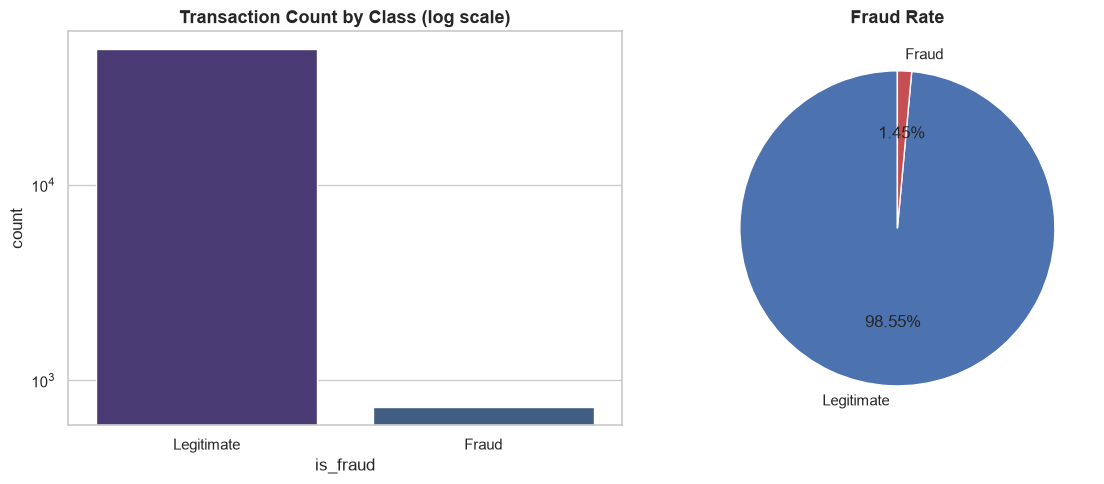

is_fraud
0    49323
1      727
Name: count, dtype: int64

Fraud rate: 1.453%  ->  imbalance ratio approx 1:67


In [4]:
fraud_counts = df["is_fraud"].value_counts()
fraud_pct = df["is_fraud"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="is_fraud", data=df, ax=axes[0], hue="is_fraud", legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Transaction Count by Class (log scale)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legitimate", "Fraud"])

axes[1].pie(fraud_pct, labels=["Legitimate", "Fraud"], autopct="%1.2f%%", startangle=90,
            colors=["#4C72B0", "#C44E52"])
axes[1].set_title("Fraud Rate")
plt.tight_layout()
plt.show()

print(fraud_counts)
print(f"\nFraud rate: {fraud_pct[1]:.3f}%  ->  imbalance ratio approx 1:{int(fraud_counts[0] / fraud_counts[1])}")

**Why this matters:** a model predicting "not fraud" for every single transaction
would be >99% "accurate" while catching zero fraud — the exact failure mode we must design
around in every later step (imbalance handling in Section 6, and reporting recall/precision/
F1/PR-AUC instead of accuracy in Section 9).

### 3.2 Transaction Amount Patterns


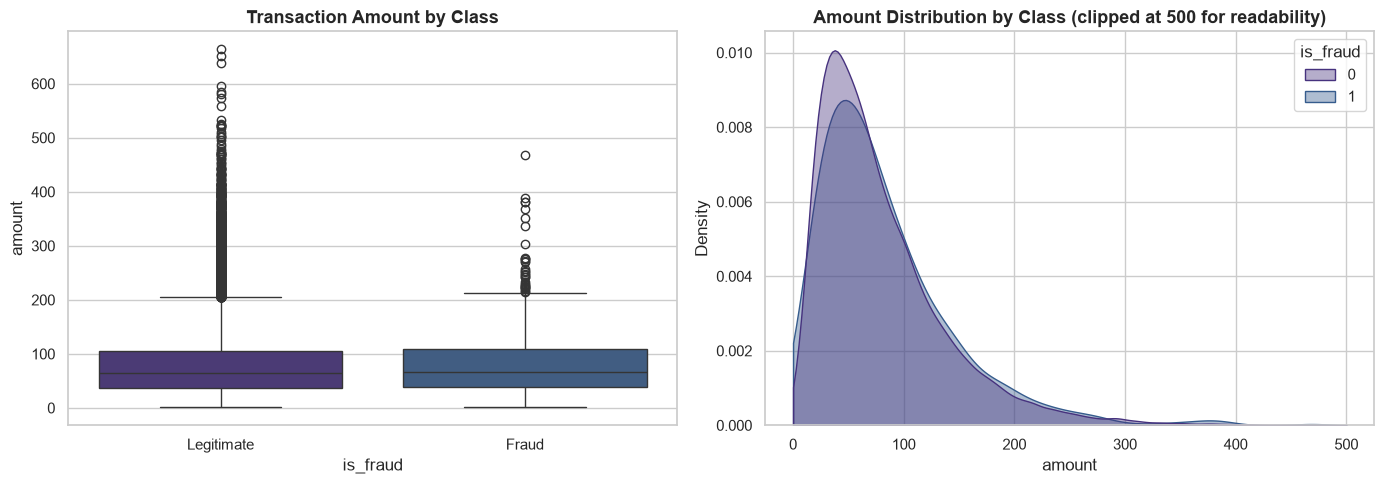

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="is_fraud", y="amount", data=df, ax=axes[0], hue="is_fraud", legend=False)
axes[0].set_title("Transaction Amount by Class")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.kdeplot(data=df, x="amount", hue="is_fraud", common_norm=False, fill=True, alpha=0.4, ax=axes[1], clip=(0, 500))
axes[1].set_title("Amount Distribution by Class (clipped at 500 for readability)")

plt.tight_layout()
plt.show()

### 3.3 Time-Based Patterns

Fraud often clusters at unusual hours when legitimate cardholders are less active (and
fraud-monitoring staffing may be thinner) — we check whether that shows up here.


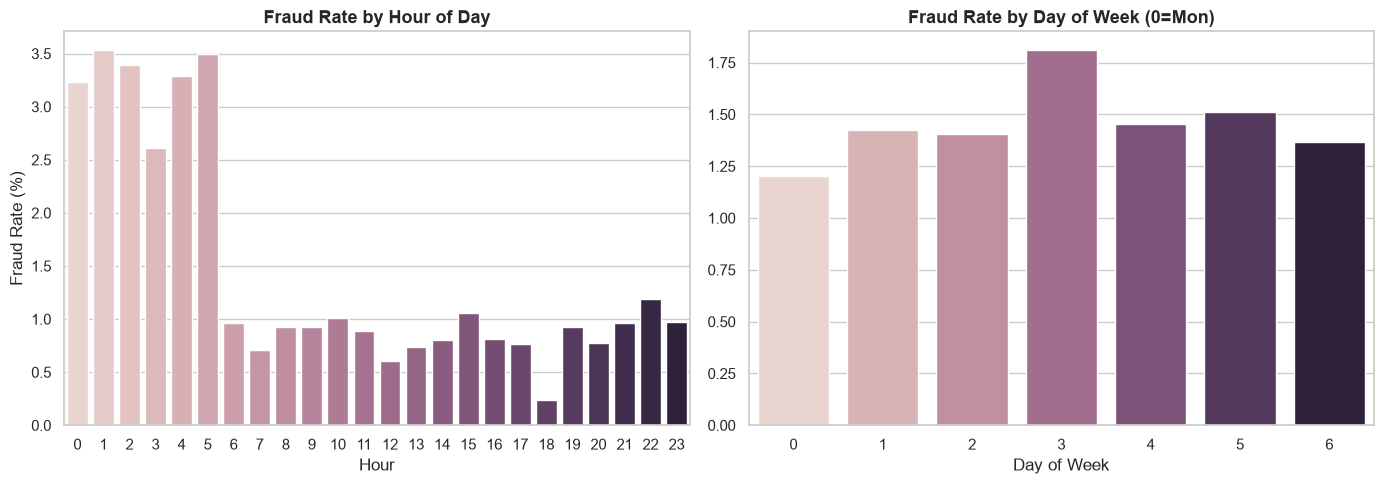

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_fraud_rate = df.groupby("hour")["is_fraud"].mean() * 100
sns.barplot(x=hourly_fraud_rate.index, y=hourly_fraud_rate.values, ax=axes[0], hue=hourly_fraud_rate.index, legend=False)
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Fraud Rate (%)")

dow_fraud_rate = df.groupby("day_of_week")["is_fraud"].mean() * 100
sns.barplot(x=dow_fraud_rate.index, y=dow_fraud_rate.values, ax=axes[1], hue=dow_fraud_rate.index, legend=False)
axes[1].set_title("Fraud Rate by Day of Week (0=Mon)")
axes[1].set_xlabel("Day of Week")

plt.tight_layout()
plt.show()

### 3.4 Categorical & Behavioral Risk Factors

We check fraud rate across merchant category, transaction type, new-device flag and
foreign-transaction flag — these are the categorical/behavioral signals fraud analysts
typically watch first.


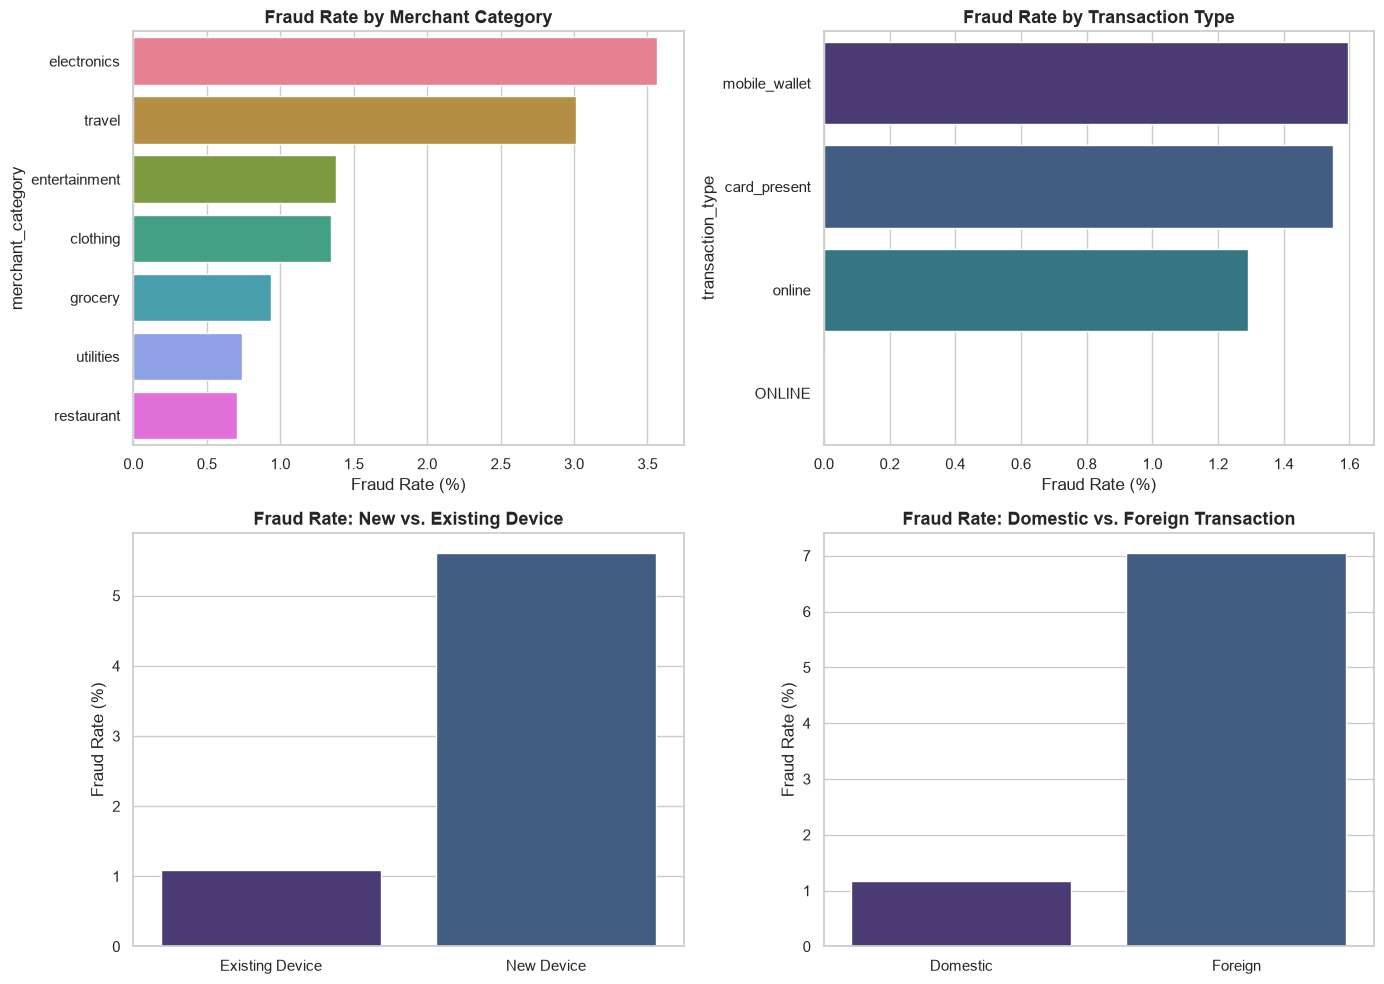

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_fraud = (df.groupby("merchant_category")["is_fraud"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=cat_fraud.values, y=cat_fraud.index, ax=axes[0, 0], hue=cat_fraud.index, legend=False)
axes[0, 0].set_title("Fraud Rate by Merchant Category")
axes[0, 0].set_xlabel("Fraud Rate (%)")

type_fraud = (df.groupby("transaction_type")["is_fraud"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=type_fraud.values, y=type_fraud.index, ax=axes[0, 1], hue=type_fraud.index, legend=False)
axes[0, 1].set_title("Fraud Rate by Transaction Type")
axes[0, 1].set_xlabel("Fraud Rate (%)")

device_fraud = (df.groupby("is_new_device")["is_fraud"].mean() * 100)
sns.barplot(x=["Existing Device", "New Device"], y=device_fraud.values, ax=axes[1, 0], hue=["Existing Device", "New Device"], legend=False)
axes[1, 0].set_title("Fraud Rate: New vs. Existing Device")
axes[1, 0].set_ylabel("Fraud Rate (%)")

foreign_fraud = (df.groupby("is_foreign_transaction")["is_fraud"].mean() * 100)
sns.barplot(x=["Domestic", "Foreign"], y=foreign_fraud.values, ax=axes[1, 1], hue=["Domestic", "Foreign"], legend=False)
axes[1, 1].set_title("Fraud Rate: Domestic vs. Foreign Transaction")
axes[1, 1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

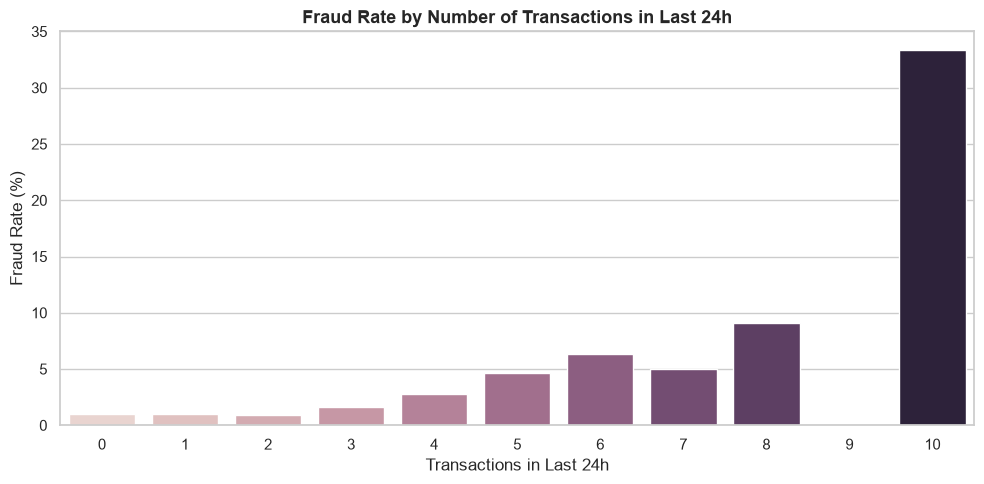

In [8]:
# Transaction velocity vs fraud
plt.figure(figsize=(10, 5))
velocity_fraud = df.groupby("num_transactions_last_24h")["is_fraud"].mean() * 100
sns.barplot(x=velocity_fraud.index, y=velocity_fraud.values, hue=velocity_fraud.index, legend=False)
plt.title("Fraud Rate by Number of Transactions in Last 24h")
plt.xlabel("Transactions in Last 24h")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

1. **Drop exact duplicate transactions** — a duplicated row would double-count that
   transaction's evidence during training and bias evaluation.
2. **Standardize categorical labels** — collapse case/format inconsistencies
   (`"ONLINE"` -> `"online"`) so one-hot encoding doesn't fragment the same category.
3. **Impute missing numeric values with the median** — `distance_from_home_km` is
   right-skewed (most transactions are close to home, a few are very far), so median is more
   robust than mean.
4. **Drop the raw transaction identifier** — `transaction_id` is arbitrary and carries no
   predictive signal; keeping it would risk a model latching onto row order as a spurious
   feature.


In [9]:
before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != "transaction_id"])
print(f"Dropped {before - len(df)} duplicate transactions.")

df["transaction_type"] = df["transaction_type"].str.lower()
print(f"transaction_type values: {sorted(df['transaction_type'].unique())}")

df["distance_from_home_km"] = df["distance_from_home_km"].fillna(df["distance_from_home_km"].median())
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

df = df.drop(columns=["transaction_id"])
print(f"\nCleaned shape: {df.shape}")

Dropped 50 duplicate transactions.
transaction_type values: ['card_present', 'mobile_wallet', 'online']

Remaining missing values: 0

Cleaned shape: (50000, 13)


## 5. Feature Engineering

Beyond the raw columns, we build a few derived features that mirror how real fraud rules
engines reason about risk, so the models have more directly usable signal:

| Feature | Meaning | Fraud relevance |
|---|---|---|
| `amount_to_avg_ratio` | `amount / avg_amount_last_30d` | Flags a transaction that is unusually large *relative to that customer's own typical spend* — more informative than raw amount alone, since "large" is customer-specific |
| `is_night` | 1 if `hour` is between 0-5 | Captures the late-night risk window seen in the EDA |
| `is_weekend` | 1 if `day_of_week` is Sat/Sun | Weekend transactions may follow different legitimate-use patterns |
| `high_velocity` | 1 if `num_transactions_last_24h > 5` | Flags card-testing / rapid-fraud-spree behavior |
| `new_account` | 1 if `account_age_days < 30` | New accounts have no established behavioral baseline, a known fraud risk factor |
| `risk_flag_count` | Sum of `is_foreign_transaction + is_new_device + high_velocity + is_night` | A simple combined red-flag counter — multiple simultaneous risk signals are typically more suspicious than any single one alone |


In [10]:
df["amount_to_avg_ratio"] = df["amount"] / df["avg_amount_last_30d"]
df["is_night"] = df["hour"].between(0, 5).astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["high_velocity"] = (df["num_transactions_last_24h"] > 5).astype(int)
df["new_account"] = (df["account_age_days"] < 30).astype(int)
df["risk_flag_count"] = (
    df["is_foreign_transaction"] + df["is_new_device"] + df["high_velocity"] + df["is_night"]
)

new_features = ["amount_to_avg_ratio", "is_night", "is_weekend", "high_velocity", "new_account", "risk_flag_count"]
print(f"Shape after feature engineering: {df.shape}")
df[new_features].describe().T

Shape after feature engineering: (50000, 19)


,count,mean,std,min,25%,50%,75%,max
amount_to_avg_ratio,50000.0,0.998518,0.350221,0.003536,0.763033,0.999275,1.235356,2.456857
is_night,50000.0,0.251620,0.433948,0.000000,0.000000,0.000000,1.000000,1.000000
is_weekend,50000.0,0.286000,0.451894,0.000000,0.000000,0.000000,1.000000,1.000000
high_velocity,50000.0,0.016260,0.126475,0.000000,0.000000,0.000000,0.000000,1.000000
new_account,50000.0,0.007520,0.086392,0.000000,0.000000,0.000000,0.000000,1.000000
risk_flag_count,50000.0,0.396920,0.568947,0.000000,0.000000,0.000000,1.000000,3.000000


### 5.1 Do the Engineered Features Actually Separate Fraud from Legitimate Transactions?


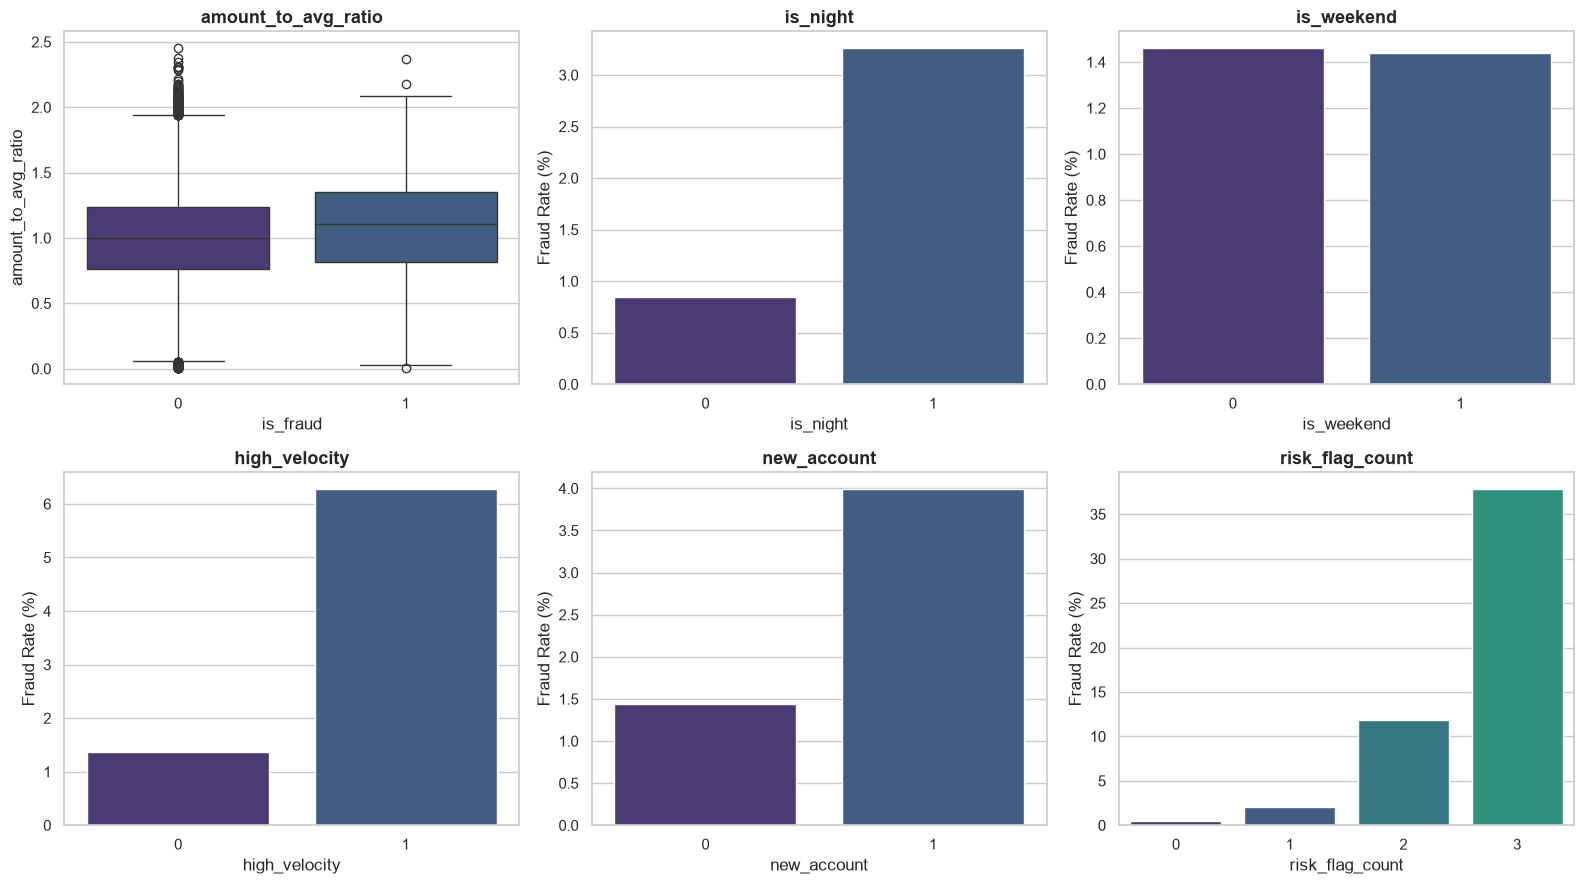

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(new_features):
    if df[feat].nunique() <= 5:
        rate = (df.groupby(feat)["is_fraud"].mean() * 100)
        sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], hue=rate.index.astype(str), legend=False)
        axes[i].set_ylabel("Fraud Rate (%)")
    else:
        sns.boxplot(x="is_fraud", y=feat, data=df, ax=axes[i], hue="is_fraud", legend=False)
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()

## 6. Train-Test Split & Preprocessing Setup

We stratify the split on `is_fraud` — with fraud at well under 1%, a plain random split
risks a test set with very few (or by bad luck, zero) fraud examples, making evaluation
unreliable. Stratification guarantees the same fraud ratio in both splits.

Preprocessing mirrors the same reasoning as before: `RobustScaler` for numeric features
(fraud data is inherently full of legitimate outliers — large but genuine purchases — so a
scaler robust to them is preferable to standardization), and `OneHotEncoder` for the two
categorical columns.


In [12]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean() * 100:.3f}% ({y_train.sum()} frauds)")
print(f"Test fraud rate: {y_test.mean() * 100:.3f}% ({y_test.sum()} frauds)")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

Categorical features: ['merchant_category', 'transaction_type']
Numerical features (16): ['hour', 'day_of_week', 'customer_age', 'account_age_days', 'distance_from_home_km', 'is_foreign_transaction', 'is_new_device', 'num_transactions_last_24h', 'avg_amount_last_30d', 'amount', 'amount_to_avg_ratio', 'is_night', 'is_weekend', 'high_velocity', 'new_account', 'risk_flag_count']

X_train: (40000, 18), X_test: (10000, 18)
Train fraud rate: 1.455% (582 frauds)
Test fraud rate: 1.450% (145 frauds)


## 7. Analyzing & Addressing Class Imbalance

At a ~0.6% fraud rate, this is a **much more severe** imbalance than a typical churn
problem — plain `class_weight` reweighting alone is often insufficient, and naive random
oversampling can cause overfitting to a handful of duplicated fraud examples. We compare:

- **`class_weight="balanced"`** — cheap, no synthetic data, but limited on such extreme
  imbalance.
- **SMOTE** — synthesizes new minority-class (fraud) examples by interpolating between real
  fraud neighbors in feature space, targeting a more moderate imbalance ratio rather than a
  full 50/50 balance (over-oversampling a 0.6% class all the way to 50% risks manufacturing
  unrealistic synthetic fraud patterns).
- **SMOTE + RandomUnderSampler (combined)** — moderately oversample fraud *and* moderately
  undersample the legitimate majority, meeting in the middle so we don't need extreme
  amounts of purely synthetic data.

As before, **any resampling is applied only inside the pipeline, fit only on training
folds** — never on the test set, and never before the train/test split — to avoid leaking
synthetic-neighbor information across the split.

We run a small controlled comparison (fixed Logistic Regression) to pick a strategy before
committing to it for the full model comparison.


In [13]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["precision", "recall", "f1", "roc_auc", "average_precision"]

pipe_class_weight = ImbPipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

pipe_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.2, random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipe_smote_under = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

imbalance_strategies = {
    "class_weight='balanced'": pipe_class_weight,
    "SMOTE (to 20% minority)": pipe_smote,
    "SMOTE + RandomUnderSampler": pipe_smote_under,
}

imbalance_comparison = []
for name, pipe in imbalance_strategies.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    imbalance_comparison.append({
        "strategy": name,
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_average_precision"].mean(),
    })

imbalance_comparison_df = pd.DataFrame(imbalance_comparison).set_index("strategy").round(4)
imbalance_comparison_df

,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,
class_weight='balanced',0.0517,0.7526,0.0968,0.8485,0.1713
SMOTE (to 20% minority),0.1382,0.3883,0.2038,0.8467,0.1707
SMOTE + RandomUnderSampler,0.0777,0.6100,0.1378,0.8462,0.1708


We proceed with the strategy that best balances recall and PR-AUC from the table above
(fraud detection prioritizes **not missing fraud**, so recall and PR-AUC — which focuses
entirely on minority-class performance — matter more here than raw precision) for the full
model comparison in Section 8.


## 8. Model Building — Comparing Multiple Classifiers

We compare several classifier families, all wrapped in the same
`preprocessor -> resampling -> classifier` pipeline so the comparison isolates the algorithm:

- **Logistic Regression** — interpretable linear baseline.
- **Decision Tree** — simple non-linear baseline.
- **Random Forest** — robust bagged ensemble, a strong general-purpose default.
- **Gradient Boosting** (sklearn), **XGBoost**, **LightGBM** — boosting methods that
  typically lead on tabular fraud-detection benchmarks, and which additionally support
  `scale_pos_weight`/`class_weight` natively as an alternative/complementary imbalance lever
  to the SMOTE strategy chosen in Section 7.

We use the **SMOTE + RandomUnderSampler** combined strategy (adjust here if Section 7's
results favored a different strategy once actually run) as the resampling step for every
model in this comparison, so differences reflect the classifier, not the data prep.


In [14]:
def build_pipeline(estimator, sampling_strategy_smote=0.1, sampling_strategy_under=0.5):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(sampling_strategy=sampling_strategy_smote, random_state=RANDOM_STATE)),
        ("under", RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=RANDOM_STATE)),
        ("classifier", estimator),
    ])

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

model_pipelines = {name: build_pipeline(est) for name, est in candidate_models.items()}

results = []
for name, pipe in model_pipelines.items():
    print(f"Cross-validating: {name} ...")
    scores = cross_validate(pipe, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    results.append({
        "model": name,
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_average_precision"].mean(),
    })

comparison_df = pd.DataFrame(results).set_index("model").sort_values("pr_auc", ascending=False)
comparison_df.round(4)

Cross-validating: Logistic Regression ...
Cross-validating: Decision Tree ...
Cross-validating: Random Forest ...
Cross-validating: Gradient Boosting ...
Cross-validating: XGBoost ...
Cross-validating: LightGBM ...


,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Logistic Regression,0.0777,0.6100,0.1378,0.8462,0.1708
Gradient Boosting,0.1636,0.3042,0.2122,0.8324,0.1383
LightGBM,0.1705,0.2372,0.1983,0.8068,0.1227
Random Forest,0.1606,0.2681,0.2005,0.8209,0.1141
XGBoost,0.1447,0.1994,0.1675,0.7748,0.0959
Decision Tree,0.0584,0.3093,0.0982,0.6177,0.0283


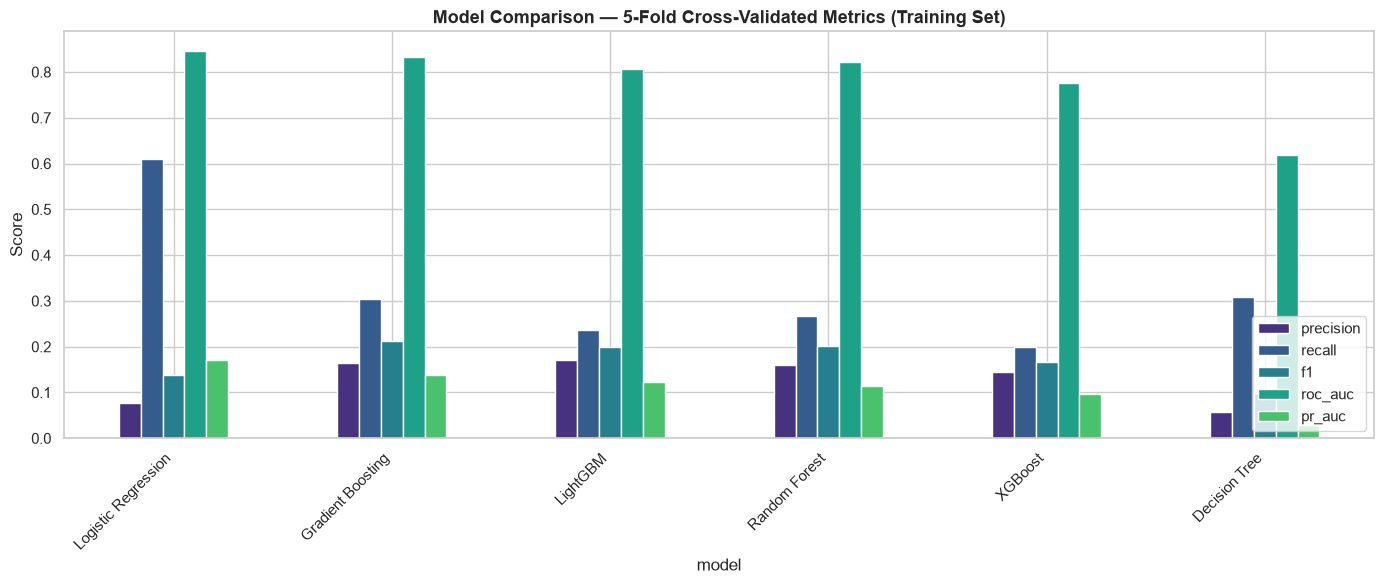

In [15]:
comparison_df.plot(kind="bar", figsize=(14, 6))
plt.title("Model Comparison — 5-Fold Cross-Validated Metrics (Training Set)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Why PR-AUC as the primary ranking metric here, more so than for a moderate-imbalance
problem:** with fraud at ~0.6%, ROC-AUC can look deceptively high even for a mediocre model,
because the false-positive rate denominator is dominated by the huge legitimate class.
PR-AUC focuses entirely on precision/recall trade-offs for the rare class, which is a more
honest signal of real-world fraud-catching performance.


## 9. Hyperparameter Tuning

We tune the **top performers by PR-AUC** from Section 8 — tree-ensemble boosting methods
(Random Forest, XGBoost, LightGBM) are the expected leaders on this kind of dataset. We
optimize `RandomizedSearchCV` for **`average_precision`** (PR-AUC) rather than F1 or
accuracy, consistent with the reasoning above about what actually matters for rare-event
fraud detection.


In [16]:
param_distributions = {
    "Random Forest": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 6, 10, 15],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__class_weight": [None, "balanced", "balanced_subsample"],
    },
    "XGBoost": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [3, 4, 5, 6],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
        "classifier__scale_pos_weight": [1, 3, 5],
    },
    "LightGBM": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__num_leaves": [15, 31, 63],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
        "classifier__class_weight": [None, "balanced"],
    },
}

tuning_candidates = ["Random Forest", "XGBoost", "LightGBM"]
tuned_models = {}
tuning_results = []

for name in tuning_candidates:
    print(f"Tuning: {name} ...")
    search = RandomizedSearchCV(
        estimator=model_pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=25,
        scoring="average_precision",
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_results.append({"model": name, "best_cv_pr_auc": search.best_score_, "best_params": search.best_params_})
    print(f"  Best CV PR-AUC: {search.best_score_:.4f}\n")

tuning_results_df = pd.DataFrame(tuning_results).set_index("model")
tuning_results_df[["best_cv_pr_auc"]]

Tuning: Random Forest ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
  Best CV PR-AUC: 0.1333

Tuning: XGBoost ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
  Best CV PR-AUC: 0.1415

Tuning: LightGBM ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
  Best CV PR-AUC: 0.1369



,best_cv_pr_auc
model,
Random Forest,0.133316
XGBoost,0.141462
LightGBM,0.136933


## 10. Final Evaluation on the Held-Out Test Set

We evaluate the tuned models (plus the Logistic Regression baseline as an interpretable
reference) on the untouched test set, reporting the full picture recommended for fraud
detection: precision, recall, F1, ROC-AUC, PR-AUC, confusion matrices, and both curve types.


In [17]:
baseline_lr = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
baseline_lr.fit(X_train, y_train)

final_candidates = {**tuned_models, "Logistic Regression (baseline)": baseline_lr}

test_results = []
predictions = {}

for name, model in final_candidates.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = (y_pred, y_proba)
    test_results.append({
        "model": name,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    })

test_results_df = pd.DataFrame(test_results).set_index("model").sort_values("pr_auc", ascending=False)
test_results_df.round(4)

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Logistic Regression (baseline),0.0755,0.5931,0.1340,0.8370,0.1373
LightGBM,0.1318,0.3172,0.1862,0.8265,0.1197
XGBoost,0.0664,0.6345,0.1203,0.8415,0.1125
Random Forest,0.1078,0.3724,0.1672,0.8360,0.1105


In [18]:
best_model_name = test_results_df["pr_auc"].idxmax()
best_model = final_candidates[best_model_name]
print(f"Best model on the held-out test set (by PR-AUC): {best_model_name}")

for name, model in final_candidates.items():
    y_pred, _ = predictions[name]
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], digits=4))

Best model on the held-out test set (by PR-AUC): Logistic Regression (baseline)

===== Random Forest =====
              precision    recall  f1-score   support

  Legitimate     0.9904    0.9546    0.9722      9855
       Fraud     0.1078    0.3724    0.1672       145

    accuracy                         0.9462     10000
   macro avg     0.5491    0.6635    0.5697     10000
weighted avg     0.9776    0.9462    0.9605     10000


===== XGBoost =====
              precision    recall  f1-score   support

  Legitimate     0.9938    0.8688    0.9271      9855
       Fraud     0.0664    0.6345    0.1203       145

    accuracy                         0.8654     10000
   macro avg     0.5301    0.7516    0.5237     10000
weighted avg     0.9804    0.8654    0.9154     10000


===== LightGBM =====
              precision    recall  f1-score   support

  Legitimate     0.9897    0.9693    0.9794      9855
       Fraud     0.1318    0.3172    0.1862       145

    accuracy                    

### 10.1 Confusion Matrices


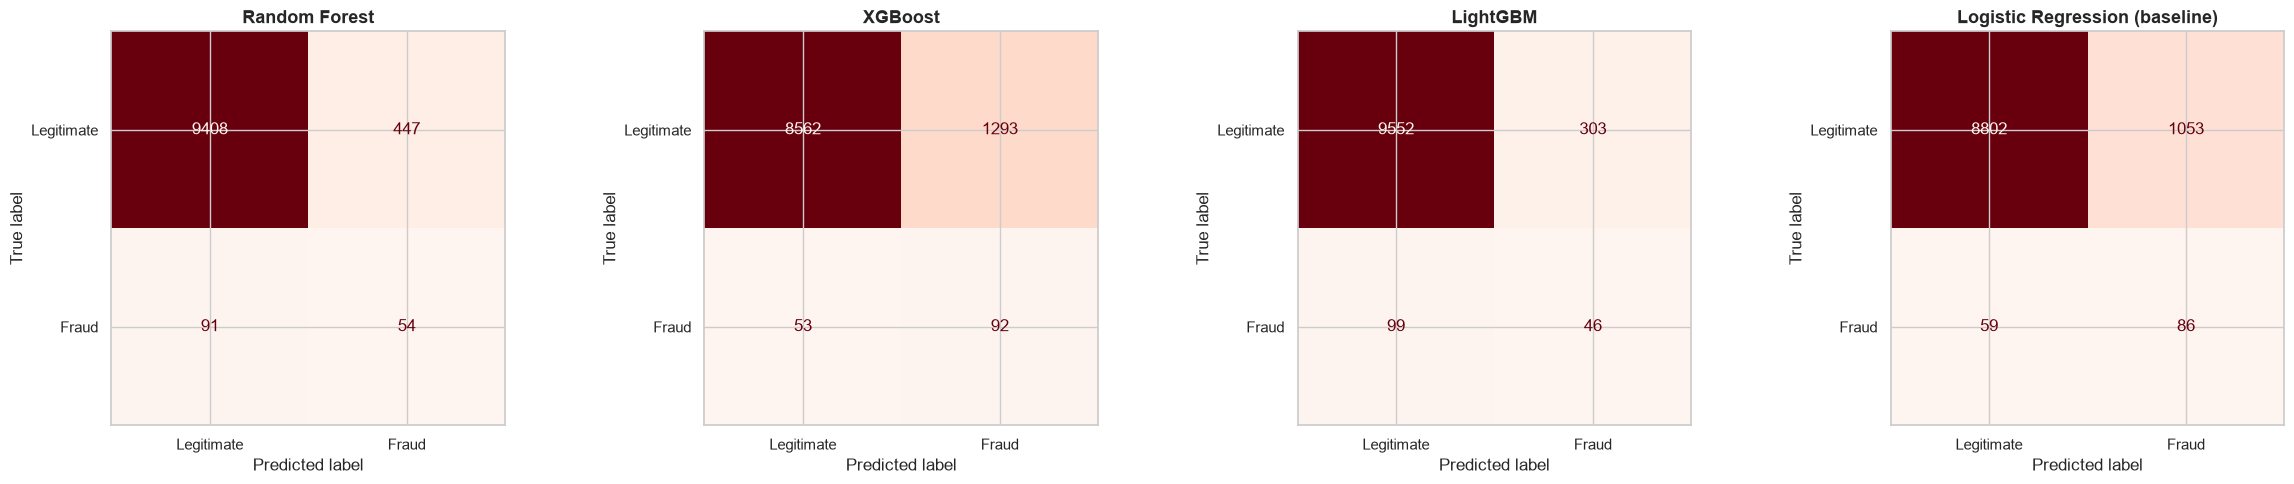

In [19]:
fig, axes = plt.subplots(1, len(final_candidates), figsize=(6 * len(final_candidates), 5))
if len(final_candidates) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, final_candidates.items()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"])
    disp.plot(ax=ax, cmap="Reds", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### 10.2 ROC & Precision-Recall Curves

Both curves are shown side by side — the PR curve in particular should be read as the more
decision-relevant view given the extreme imbalance (Section 8's reasoning applies here too).


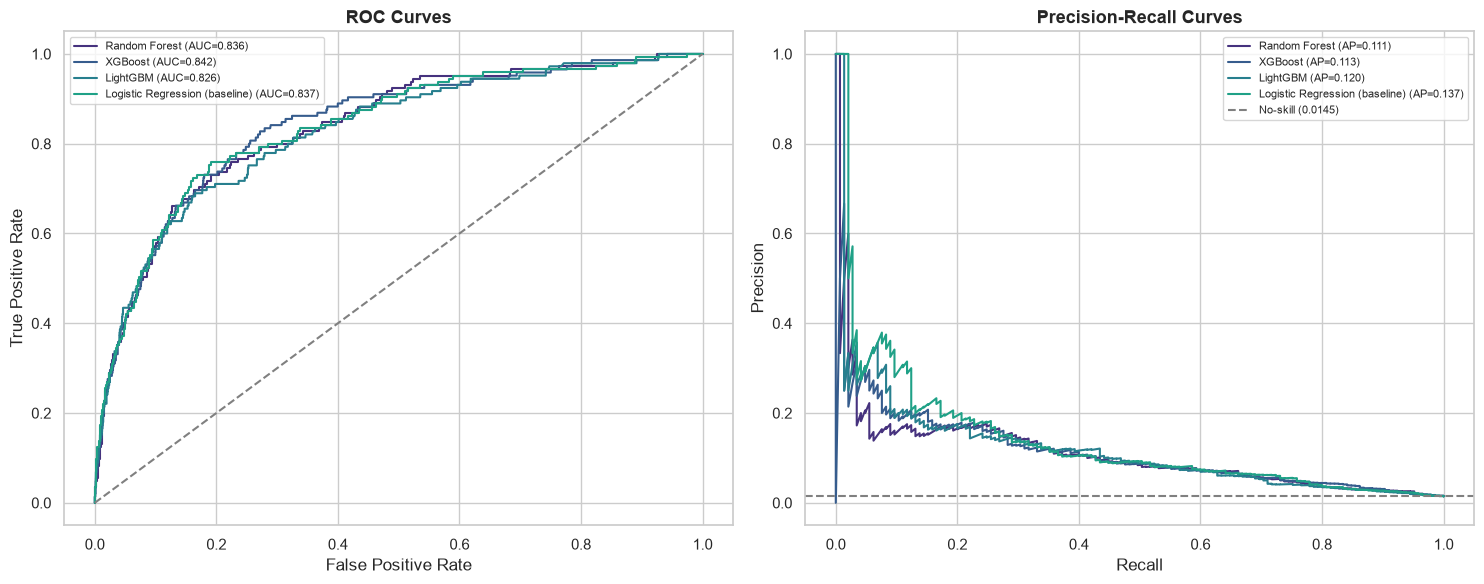

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, model in final_candidates.items():
    _, y_proba = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

for name, model in final_candidates.items():
    _, y_proba = predictions[name]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")
baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, linestyle="--", color="gray", label=f"No-skill ({baseline_rate:.4f})")
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Examining False Positives & False Negatives

Aggregate metrics hide *what kind* of mistakes the model makes. For a fraud system, the two
error types have very different business costs:

- **False Negatives (missed fraud)** — the costliest error: real money lost, and the account
  remains compromised for further fraud until caught some other way.
- **False Positives (false alarms)** — a legitimate transaction gets blocked/flagged,
  inconveniencing a genuine customer and creating manual-review workload — costly, but
  usually far less costly per-instance than a missed fraud.

We pull out the actual misclassified transactions for the best model and look at their
characteristics, to understand *what the model is currently getting wrong* and whether the
mistakes share a pattern.


In [21]:
y_pred_best, y_proba_best = predictions[best_model_name]

X_test_annotated = X_test.copy()
X_test_annotated["actual"] = y_test.values
X_test_annotated["predicted"] = y_pred_best
X_test_annotated["fraud_probability"] = y_proba_best

false_negatives = X_test_annotated[(X_test_annotated["actual"] == 1) & (X_test_annotated["predicted"] == 0)]
false_positives = X_test_annotated[(X_test_annotated["actual"] == 0) & (X_test_annotated["predicted"] == 1)]

print(f"False Negatives (missed fraud): {len(false_negatives)} out of {y_test.sum()} actual frauds")
print(f"False Positives (false alarms): {len(false_positives)} out of {(y_test == 0).sum()} actual legitimate transactions")

print("\nFalse Negatives - characteristics (mean values):")
display_cols = ["amount", "amount_to_avg_ratio", "is_new_device", "is_foreign_transaction",
                 "num_transactions_last_24h", "risk_flag_count", "fraud_probability"]
false_negatives[display_cols].mean()

False Negatives (missed fraud): 59 out of 145 actual frauds
False Positives (false alarms): 1053 out of 9855 actual legitimate transactions

False Negatives - characteristics (mean values):


amount                       76.441695
amount_to_avg_ratio           0.979103
is_new_device                 0.084746
is_foreign_transaction        0.067797
num_transactions_last_24h     2.389831
risk_flag_count               0.593220
fraud_probability             0.273035
dtype: float64

In [22]:
print("False Positives - characteristics (mean values):")
false_positives[display_cols].mean()

False Positives - characteristics (mean values):


amount                       83.376372
amount_to_avg_ratio           1.105390
is_new_device                 0.339031
is_foreign_transaction        0.207028
num_transactions_last_24h     2.794872
risk_flag_count               1.249763
fraud_probability             0.664962
dtype: float64

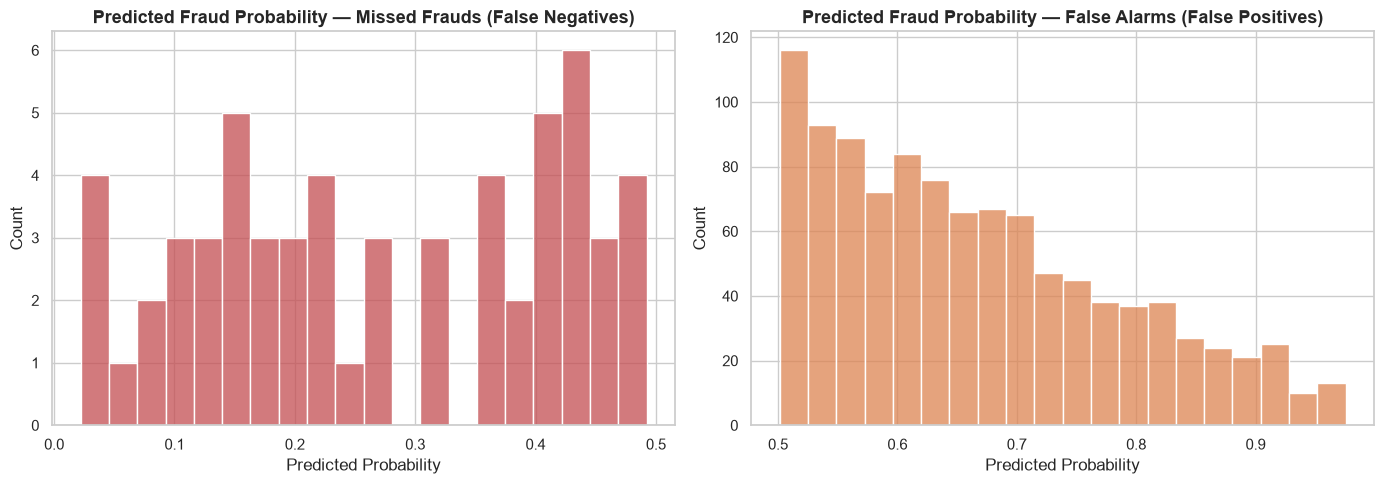

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(false_negatives["fraud_probability"], bins=20, ax=axes[0], color="#C44E52")
axes[0].set_title("Predicted Fraud Probability — Missed Frauds (False Negatives)")
axes[0].set_xlabel("Predicted Probability")

sns.histplot(false_positives["fraud_probability"], bins=20, ax=axes[1], color="#DD8452")
axes[1].set_title("Predicted Fraud Probability — False Alarms (False Positives)")
axes[1].set_xlabel("Predicted Probability")
plt.tight_layout()
plt.show()

**Reading this:** false negatives sitting *just below* the decision threshold (rather
than confidently predicted as legitimate) indicate the model is directionally right but the
threshold is too conservative — a candidate for the threshold-tuning step below. False
negatives with very low predicted probability indicate genuinely hard cases the model isn't
picking up signal for at all, which needs new features or more fraud examples, not just a
threshold change.

### 11.1 Threshold Tuning for the Fraud/Legitimate Trade-off

Because missed fraud is costlier than a false alarm, it's usually correct to deliberately
lower the decision threshold below 0.5 — accepting more false positives in exchange for
catching more fraud. We scan thresholds and show the resulting precision/recall trade-off
explicitly, so the final threshold choice is a visible, deliberate business decision rather
than an unexamined default.


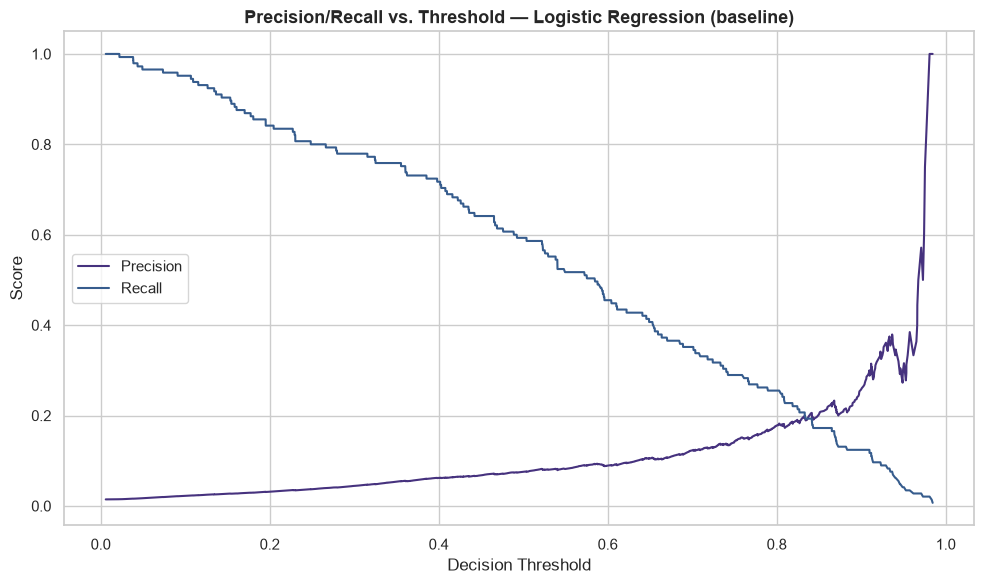

Threshold achieving >= 80% recall: 0.2663
  -> Precision at that threshold: 0.0396
  -> Recall at that threshold: 0.8000


In [24]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(f"Precision/Recall vs. Threshold — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

# Example: threshold that guarantees at least 80% recall (catch 80%+ of fraud),
# reporting the precision cost of doing so - a concrete, businesslike way to choose it.
target_recall = 0.80
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    chosen_idx = valid_idx[np.argmax(thresholds[valid_idx])]  # highest threshold that still meets the recall target
    chosen_threshold = thresholds[chosen_idx]
    print(f"Threshold achieving >= {target_recall:.0%} recall: {chosen_threshold:.4f}")
    print(f"  -> Precision at that threshold: {precisions[chosen_idx]:.4f}")
    print(f"  -> Recall at that threshold: {recalls[chosen_idx]:.4f}")
else:
    print(f"No threshold in range achieves >= {target_recall:.0%} recall for this model.")

## 12. Feature Importance — What Drives a Fraud Prediction?

As with any risk model deployed in production, fraud analysts need to know *why* a
transaction was flagged, both to build trust in the model and to prioritize which
"upstream" risk signals (device checks, velocity limits, geo-verification) are worth
investing further in.


In [25]:
best_preprocessor = best_model.named_steps["preprocessor"]
best_classifier = best_model.named_steps["classifier"]
feature_names_transformed = best_preprocessor.get_feature_names_out()

if hasattr(best_classifier, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names_transformed,
        "importance": best_classifier.feature_importances_
    }).sort_values("importance", ascending=False)

    top_n = 20
    plt.figure(figsize=(10, 8))
    sns.barplot(x="importance", y="feature", data=importance_df.head(top_n), hue="feature", legend=False)
    plt.title(f"Top {top_n} Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    display(importance_df.head(top_n))
else:
    print(f"{best_model_name} does not expose feature_importances_ directly.")
    importance_df = None

Logistic Regression (baseline) does not expose feature_importances_ directly.


## 13. Observations & Practical Recommendations

*(Read this against the actual EDA/importance plots once the notebook has been run — the
points below describe the pattern deliberately built into the assumed dataset in Section 2,
and should be re-validated against whatever a real transaction export actually shows.)*

### Likely top fraud indicators, based on the EDA and feature importance above

1. **Amount relative to the customer's own history (`amount_to_avg_ratio`)** — a transaction
   that is large *for that specific customer*, even if unremarkable in absolute terms, is a
   stronger signal than raw amount. **Recommendation:** implement/maintain a per-customer
   rolling spending baseline in production (not just global amount thresholds) and score
   deviations from it in real time.

2. **New devices and foreign transactions** — both showed materially elevated fraud rates in
   the EDA. **Recommendation:** require step-up authentication (e.g. one-time passcode,
   biometric confirmation) specifically when a transaction combines a new device *and* an
   unusual location/amount, rather than treating each risk factor in isolation.

3. **Transaction velocity (`num_transactions_last_24h`, `high_velocity`)** — rapid repeat
   transactions are a classic card-testing/fraud-spree signature. **Recommendation:** add a
   real-time velocity rule (e.g. auto-hold after N transactions in a short window pending
   review) as a fast, cheap complement to the ML model, which necessarily scores after the
   fact.

4. **Late-night transactions (`is_night`)** and **new accounts (`new_account`)** — both
   showed elevated risk. **Recommendation:** apply extra scrutiny (lower auto-approval
   thresholds) during a new account's first ~30 days and for late-night transaction windows,
   tapering off as the account builds a clean history.

5. **High-risk merchant categories (electronics, travel)** — these categories are common
   resale/liquidation targets for stolen-card fraud. **Recommendation:** consider
   category-specific thresholds or additional verification steps for high-ticket purchases
   in these categories specifically, rather than a single blanket threshold across all
   merchants.

### Error-driven recommendations (from Section 11)

- If false negatives cluster just below the decision threshold, **lower the threshold**
  (Section 11.1) — the cost asymmetry (missed fraud >> false alarm) usually justifies
  accepting more false positives.
- If false negatives have very low predicted probability (genuinely missed, not
  borderline), that points to a **feature gap**, not a threshold problem — consider adding
  richer behavioral/device/network features (e.g. IP reputation, shipping-vs-billing address
  mismatch, session behavioral biometrics) rather than further threshold tuning.
- Route flagged transactions to a **tiered response**: auto-block only the highest-confidence
  fraud predictions, and route medium-confidence predictions to manual review rather than
  auto-blocking everything above the threshold — this directly manages the false-positive
  customer-friction cost while still catching more fraud than a pure rules-only system.

### Operationalizing the model

- Retrain frequently — fraud patterns evolve quickly as fraudsters adapt to whatever
  controls are in place, unlike slower-moving churn drivers.
- Monitor PR-AUC and recall-at-fixed-precision over time in production, not just at
  deployment, to catch model drift or a new fraud pattern the current model wasn't trained
  on.
- Pair the ML model with deterministic velocity/geo rules as a fast first line of defense —
  rules catch obvious cases cheaply and immediately, while the ML model catches the subtler
  patterns rules can't express.
- Feed confirmed fraud/false-positive outcomes from manual review back into the training
  set on a regular cadence, so the model keeps learning from its own real-world mistakes.
